# DeepGain MPC Model — Validation & Analysis (RIR-based)\n\nTrained on MPC-free synthetic data (no hidden fatigue state in generator).\nModel predicts **RIR (0-5)** from latent per-muscle MPC state.\n\nThree learned components:\n- **f** (fatigue): MPC drop per muscle after a set\n- **g** (RIR predictor): predicted RIR from current MPC state\n- **r** (recovery): MPC recovery toward 1.0 over time

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import warnings, math
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
EMBED_DIM, HIDDEN_DIM = 32, 128
WEIGHT_SCALE, REPS_SCALE, RIR_SCALE = 200.0, 30.0, 5.0
DT_SCALE = np.log1p(168.0)

ALL_MUSCLES = ["chest","anterior_delts","lateral_delts","rear_delts","upper_traps","rhomboids",
    "triceps","biceps","brachialis","lats","quads","hamstrings","glutes","adductors","erectors","calves"]
NUM_MUSCLES = len(ALL_MUSCLES)
MUSCLE_TO_IDX = {m: i for i, m in enumerate(ALL_MUSCLES)}

EXERCISE_MUSCLES = {
    "bench_press":{"chest":0.85,"triceps":0.55,"anterior_delts":0.60},
    "incline_bench":{"chest":0.70,"anterior_delts":0.75,"triceps":0.50},
    "close_grip_bench":{"chest":0.65,"triceps":0.75,"anterior_delts":0.55},
    "dumbbell_bench":{"chest":0.82,"triceps":0.45,"anterior_delts":0.55},
    "ohp":{"anterior_delts":0.85,"triceps":0.65,"chest":0.20,"upper_traps":0.40},
    "dumbbell_ohp":{"anterior_delts":0.80,"triceps":0.60,"upper_traps":0.35},
    "dips":{"chest":0.70,"triceps":0.65,"anterior_delts":0.45},
    "barbell_row":{"lats":0.80,"biceps":0.55,"rear_delts":0.50,"erectors":0.40,"upper_traps":0.35,"rhomboids":0.45},
    "lat_pulldown":{"lats":0.75,"biceps":0.50,"rear_delts":0.35,"rhomboids":0.40},
    "cable_row":{"lats":0.70,"biceps":0.45,"rear_delts":0.40,"rhomboids":0.50,"upper_traps":0.30},
    "pull_up":{"lats":0.82,"biceps":0.55,"rear_delts":0.35,"rhomboids":0.40},
    "squat":{"quads":0.85,"glutes":0.60,"hamstrings":0.35,"erectors":0.45,"adductors":0.40},
    "front_squat":{"quads":0.90,"glutes":0.50,"erectors":0.55,"adductors":0.35},
    "deadlift":{"glutes":0.70,"hamstrings":0.55,"erectors":0.80,"quads":0.40,"upper_traps":0.50,"lats":0.30,"adductors":0.35},
    "rdl":{"hamstrings":0.80,"glutes":0.55,"erectors":0.50,"adductors":0.25},
    "leg_press":{"quads":0.80,"glutes":0.50,"adductors":0.35},
    "bulgarian_split_squat":{"quads":0.80,"glutes":0.65,"hamstrings":0.30,"adductors":0.40},
    "hip_thrust":{"glutes":0.85,"hamstrings":0.40,"adductors":0.30},
    "tricep_pushdown":{"triceps":0.90},"overhead_tricep_ext":{"triceps":0.85},
    "bicep_curl":{"biceps":0.90},"hammer_curl":{"biceps":0.75,"brachialis":0.60},
    "lateral_raise":{"lateral_delts":0.85,"upper_traps":0.30},
    "face_pull":{"rear_delts":0.70,"upper_traps":0.40,"rhomboids":0.35},
    "leg_curl":{"hamstrings":0.85},"leg_extension":{"quads":0.85},"calf_raise":{"calves":0.90},
}
ALL_EXERCISES = list(EXERCISE_MUSCLES.keys())
NUM_EXERCISES = len(ALL_EXERCISES)
EXERCISE_TO_IDX = {e: i for i, e in enumerate(ALL_EXERCISES)}

INVOLVEMENT_MATRIX = np.zeros((NUM_EXERCISES, NUM_MUSCLES), dtype=np.float32)
for ex, ms in EXERCISE_MUSCLES.items():
    for m, c in ms.items():
        INVOLVEMENT_MATRIX[EXERCISE_TO_IDX[ex], MUSCLE_TO_IDX[m]] = c

print(f"Exercises: {NUM_EXERCISES}, Muscles: {NUM_MUSCLES}, Device: {DEVICE}")

In [ ]:
# --- Data Loading ---
df = pd.read_csv("training_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
df["exercise_idx"] = df["exercise"].map(EXERCISE_TO_IDX)
df = df.dropna(subset=["exercise_idx"])
df["exercise_idx"] = df["exercise_idx"].astype(int)
df["delta_t_hours"] = df.groupby("user_id")["timestamp"].diff().dt.total_seconds() / 3600.0
df["delta_t_hours"] = df["delta_t_hours"].fillna(0.0)

user_ids = df["user_id"].unique()
rng = np.random.RandomState(42)
rng.shuffle(user_ids)
split = int(0.7 * len(user_ids))
train_users, test_users = set(user_ids[:split]), set(user_ids[split:])
train_df = df[df["user_id"].isin(train_users)].copy()
test_df = df[df["user_id"].isin(test_users)].copy()

def build_user_sequences(user_df):
    seqs = []
    for uid, grp in user_df.groupby("user_id"):
        seqs.append({"user_id": uid,
            "exercise_idx": torch.tensor(grp["exercise_idx"].values, dtype=torch.long),
            "weight": torch.tensor(grp["weight_kg"].values / WEIGHT_SCALE, dtype=torch.float32),
            "reps": torch.tensor(grp["reps"].values / REPS_SCALE, dtype=torch.float32),
            "rir": torch.tensor(grp["rir"].values / RIR_SCALE, dtype=torch.float32),
            "delta_t": torch.tensor(np.log1p(grp["delta_t_hours"].values) / DT_SCALE, dtype=torch.float32),
            "timestamps": grp["timestamp"].values})
    return seqs

def chunk_seq(seq, L=256):
    T = len(seq["exercise_idx"])
    if T <= L: return [seq]
    chunks = []
    for s in range(0, T, L):
        e = min(s+L, T)
        c = {k: seq[k][s:e] for k in ["exercise_idx","weight","reps","rir","delta_t"]}
        c["user_id"] = seq["user_id"]
        if "timestamps" in seq: c["timestamps"] = seq["timestamps"][s:e]
        chunks.append(c)
    return chunks

class DS(Dataset):
    def __init__(self, udf):
        self.chunks = []
        for s in build_user_sequences(udf):
            self.chunks.extend(chunk_seq(s))
    def __len__(self): return len(self.chunks)
    def __getitem__(self, i): return self.chunks[i]

def collate(batch):
    ml = max(len(b["exercise_idx"]) for b in batch)
    B = len(batch)
    o = {k: torch.zeros(B, ml, dtype=torch.long if k=="exercise_idx" else torch.float32)
         for k in ["exercise_idx","weight","reps","rir","delta_t"]}
    o["mask"] = torch.zeros(B, ml)
    for i, b in enumerate(batch):
        T = len(b["exercise_idx"])
        for k in o:
            if k == "mask": o[k][i,:T] = 1.0
            elif k in b: o[k][i,:T] = b[k]
    return o

test_ds = DS(test_df)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=collate)
print(f"Train: {len(train_df):,} sets ({len(train_users)} users) | Test: {len(test_df):,} sets ({len(test_users)} users)")

Train: 1,276,495 sets (350 users) | Test: 537,588 sets (150 users)


In [ ]:
# --- Model Architecture + Load Pretrained ---
class FatigueNet(nn.Module):
    def __init__(self, E, H):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(4+2*E,H),nn.ReLU(),nn.Linear(H,H),nn.ReLU(),nn.Linear(H,H//2),nn.ReLU(),nn.Linear(H//2,1),nn.Sigmoid())
        nn.init.constant_(self.net[-2].bias, -2.0)
    def forward(self, w, r, rir, mpc, ee, me):
        return self.net(torch.cat([w.unsqueeze(-1),r.unsqueeze(-1),rir.unsqueeze(-1),mpc.unsqueeze(-1),ee,me],-1)).squeeze(-1)

class RIRNet(nn.Module):
    def __init__(self, E, H, M):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2+E+M,H),nn.ReLU(),nn.Linear(H,H),nn.ReLU(),nn.Linear(H,H//2),nn.ReLU(),nn.Linear(H//2,1))
    def forward(self, w, r, ee, mpc):
        return torch.sigmoid(self.net(torch.cat([w.unsqueeze(-1),r.unsqueeze(-1),ee,mpc],-1)).squeeze(-1))

class RecoveryNet(nn.Module):
    def __init__(self, E, H):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2+E,H),nn.ReLU(),nn.Linear(H,H),nn.ReLU(),nn.Linear(H,H//2),nn.ReLU(),nn.Linear(H//2,1))
    def forward(self, mpc, dt, me):
        return torch.sigmoid(self.net(torch.cat([mpc.unsqueeze(-1),dt.unsqueeze(-1),me],-1)).squeeze(-1))

class DeepGainModel(nn.Module):
    def __init__(self, NE, NM, E, H):
        super().__init__()
        self.num_muscles = NM
        self.exercise_embed = nn.Embedding(NE, E)
        self.muscle_embed = nn.Embedding(NM, E)
        self.f_net = FatigueNet(E, H)
        self.g_net = RIRNet(E, H, NM)
        self.r_net = RecoveryNet(E, H)
        self.register_buffer("involvement", torch.tensor(INVOLVEMENT_MATRIX))

    def forward(self, ex, w, r, rir_t, dt, mask):
        B, T = ex.shape; M = self.num_muscles; dev = ex.device
        mpc = torch.ones(B, M, device=dev); preds = []
        me = self.muscle_embed(torch.arange(M, device=dev))
        me_exp = me.unsqueeze(0).expand(B,-1,-1); Ed = me.shape[-1]
        for t in range(T):
            if t > 0:
                mpc = self.r_net(mpc.reshape(-1), dt[:,t].unsqueeze(1).expand(-1,M).reshape(-1), me_exp.reshape(-1,Ed)).reshape(B,M)
            ee = self.exercise_embed(ex[:,t])
            preds.append(self.g_net(w[:,t], r[:,t], ee, mpc))
            inv = self.involvement[ex[:,t]]
            drop = self.f_net(w[:,t].unsqueeze(1).expand(-1,M).reshape(-1), r[:,t].unsqueeze(1).expand(-1,M).reshape(-1),
                rir_t[:,t].unsqueeze(1).expand(-1,M).reshape(-1), mpc.reshape(-1),
                ee.unsqueeze(1).expand(-1,M,-1).reshape(-1,Ed), me_exp.reshape(-1,Ed)).reshape(B,M)
            mpc = (mpc * (1.0 - inv * drop)).clamp(min=0.1)
        return torch.stack(preds, 1), mpc

    def forward_with_mpc_history(self, ex, w, r, rir_t, dt):
        B,T = ex.shape; M = self.num_muscles; dev = ex.device
        mpc = torch.ones(1,M,device=dev); preds=[]; hist=[mpc[0].detach().cpu().numpy().copy()]
        me = self.muscle_embed(torch.arange(M,device=dev)); me_exp = me.unsqueeze(0); Ed = me.shape[-1]
        for t in range(T):
            if t > 0:
                mpc = self.r_net(mpc.reshape(-1), dt[:,t].unsqueeze(1).expand(-1,M).reshape(-1), me_exp.reshape(-1,Ed)).reshape(1,M)
            ee = self.exercise_embed(ex[:,t])
            preds.append(self.g_net(w[:,t], r[:,t], ee, mpc).item())
            inv = self.involvement[ex[:,t]]
            drop = self.f_net(w[:,t].unsqueeze(1).expand(-1,M).reshape(-1), r[:,t].unsqueeze(1).expand(-1,M).reshape(-1),
                rir_t[:,t].unsqueeze(1).expand(-1,M).reshape(-1), mpc.reshape(-1),
                ee.unsqueeze(1).expand(-1,M,-1).reshape(-1,Ed), me_exp.reshape(-1,Ed)).reshape(1,M)
            mpc = (mpc * (1.0 - inv * drop)).clamp(min=0.1)
            hist.append(mpc[0].detach().cpu().numpy().copy())
        return np.array(preds), np.array(hist)

model = DeepGainModel(NUM_EXERCISES, NUM_MUSCLES, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
model.load_state_dict(torch.load("deepgain_model_chest.pt", map_location=DEVICE))
model.eval()
print(f"Loaded model ({sum(p.numel() for p in model.parameters()):,} params)")

In [ ]:
# --- Evaluation Metrics ---
@torch.no_grad()
def collect_predictions(mdl, loader):
    mdl.eval()
    P, T, E = [], [], []
    for b in loader:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        pred, _ = mdl(b["exercise_idx"], b["weight"], b["reps"], b["rir"], b["delta_t"], b["mask"])
        m = b["mask"].bool()
        P.append((pred[m]*RIR_SCALE).cpu().numpy())
        T.append((b["rir"][m]*RIR_SCALE).cpu().numpy())
        E.append(b["exercise_idx"][m].cpu().numpy())
    return np.concatenate(P), np.concatenate(T), np.concatenate(E)

test_preds, test_targets, test_exercises = collect_predictions(model, test_loader)
mse = np.mean((test_preds - test_targets)**2)
mae = np.mean(np.abs(test_preds - test_targets))
rmse = np.sqrt(mse)
corr = np.corrcoef(test_preds, test_targets)[0, 1]

print(f"Test Metrics (RIR 0-5):")
print(f"  RMSE: {rmse:.3f}  MAE: {mae:.3f}  R: {corr:.3f}")

exercise_maes = {}
for ei in range(NUM_EXERCISES):
    m = test_exercises == ei
    if m.sum() > 0:
        exercise_maes[ALL_EXERCISES[ei]] = np.mean(np.abs(test_preds[m] - test_targets[m]))

print(f"\nPer-exercise MAE:")
for ex, v in sorted(exercise_maes.items(), key=lambda x: x[1]):
    print(f"  {ex:25s}: {v:.3f}")

Test Metrics (RIR 0-5):
  RMSE: 0.976  MAE: 0.762  R: 0.832

Per-exercise MAE:
  lat_pulldown             : 0.628
  incline_bench            : 0.681
  cable_row                : 0.683
  bulgarian_split_squat    : 0.699
  deadlift                 : 0.713
  close_grip_bench         : 0.716
  pull_up                  : 0.721
  squat                    : 0.723
  dumbbell_ohp             : 0.736
  rdl                      : 0.747
  dips                     : 0.751
  ohp                      : 0.753
  calf_raise               : 0.755
  bench_press              : 0.757
  dumbbell_bench           : 0.757
  hip_thrust               : 0.764
  leg_press                : 0.764
  barbell_row              : 0.783
  leg_extension            : 0.809
  overhead_tricep_ext      : 0.809
  leg_curl                 : 0.811
  lateral_raise            : 0.824
  hammer_curl              : 0.825
  bicep_curl               : 0.827
  face_pull                : 0.835
  front_squat              : 0.839
  tricep_pu

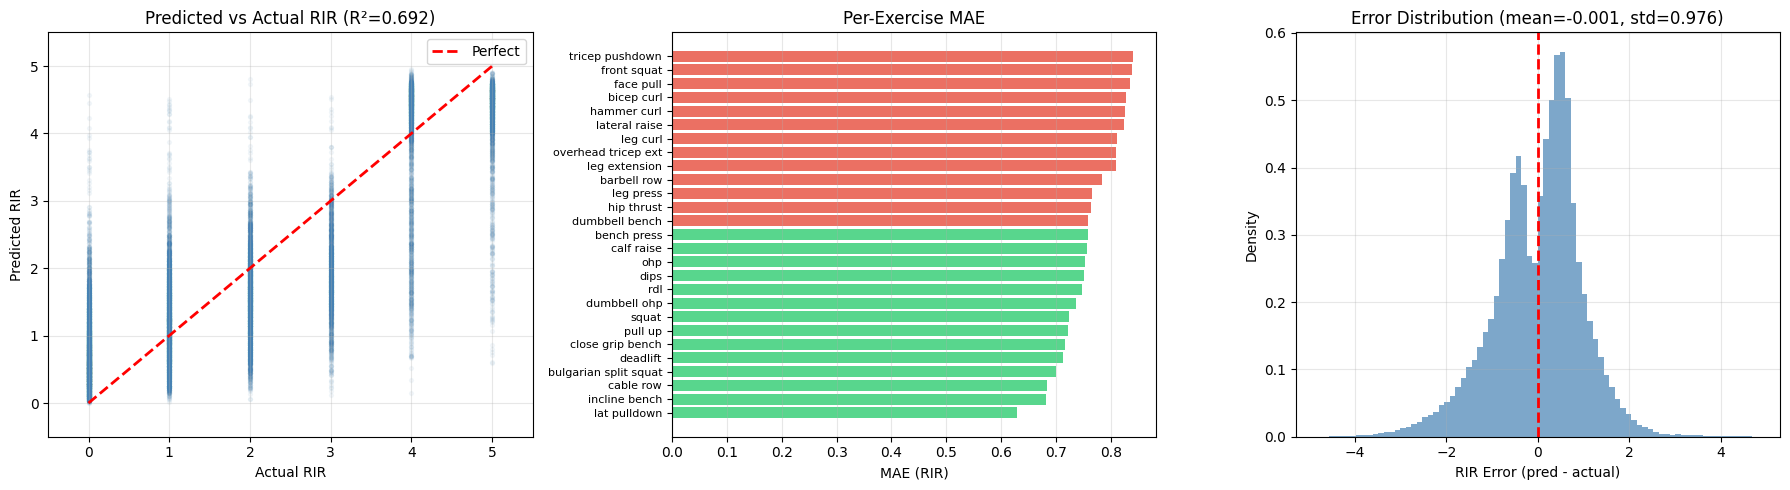

In [ ]:
# --- RIR Prediction Accuracy ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
muscle_colors = plt.cm.tab20(np.linspace(0, 1, NUM_MUSCLES))

ax = axes[0]
idx = np.random.choice(len(test_preds), min(15000, len(test_preds)), replace=False)
ax.scatter(test_targets[idx], test_preds[idx], alpha=0.05, s=8, c="steelblue")
ax.plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect")
ax.set_xlabel("Actual RIR"); ax.set_ylabel("Predicted RIR")
ax.set_title(f"Predicted vs Actual RIR (R²={corr**2:.3f})")
ax.legend(); ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 5.5); ax.grid(True, alpha=0.3)

ax = axes[1]
se = sorted(exercise_maes.items(), key=lambda x: x[1], reverse=True)
names, vals = [e[0].replace("_"," ") for e in se], [e[1] for e in se]
colors = ["#e74c3c" if v > np.median(vals) else "#2ecc71" for v in vals]
ax.barh(range(len(names)), vals, color=colors, alpha=0.8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("MAE (RIR)"); ax.set_title("Per-Exercise MAE"); ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis="x")

ax = axes[2]
errors = test_preds - test_targets
ax.hist(errors, bins=80, color="steelblue", alpha=0.7, density=True)
ax.axvline(0, color="red", linestyle="--", linewidth=2)
ax.set_xlabel("RIR Error (pred - actual)"); ax.set_ylabel("Density")
ax.set_title(f"Error Distribution (mean={errors.mean():.3f}, std={errors.std():.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

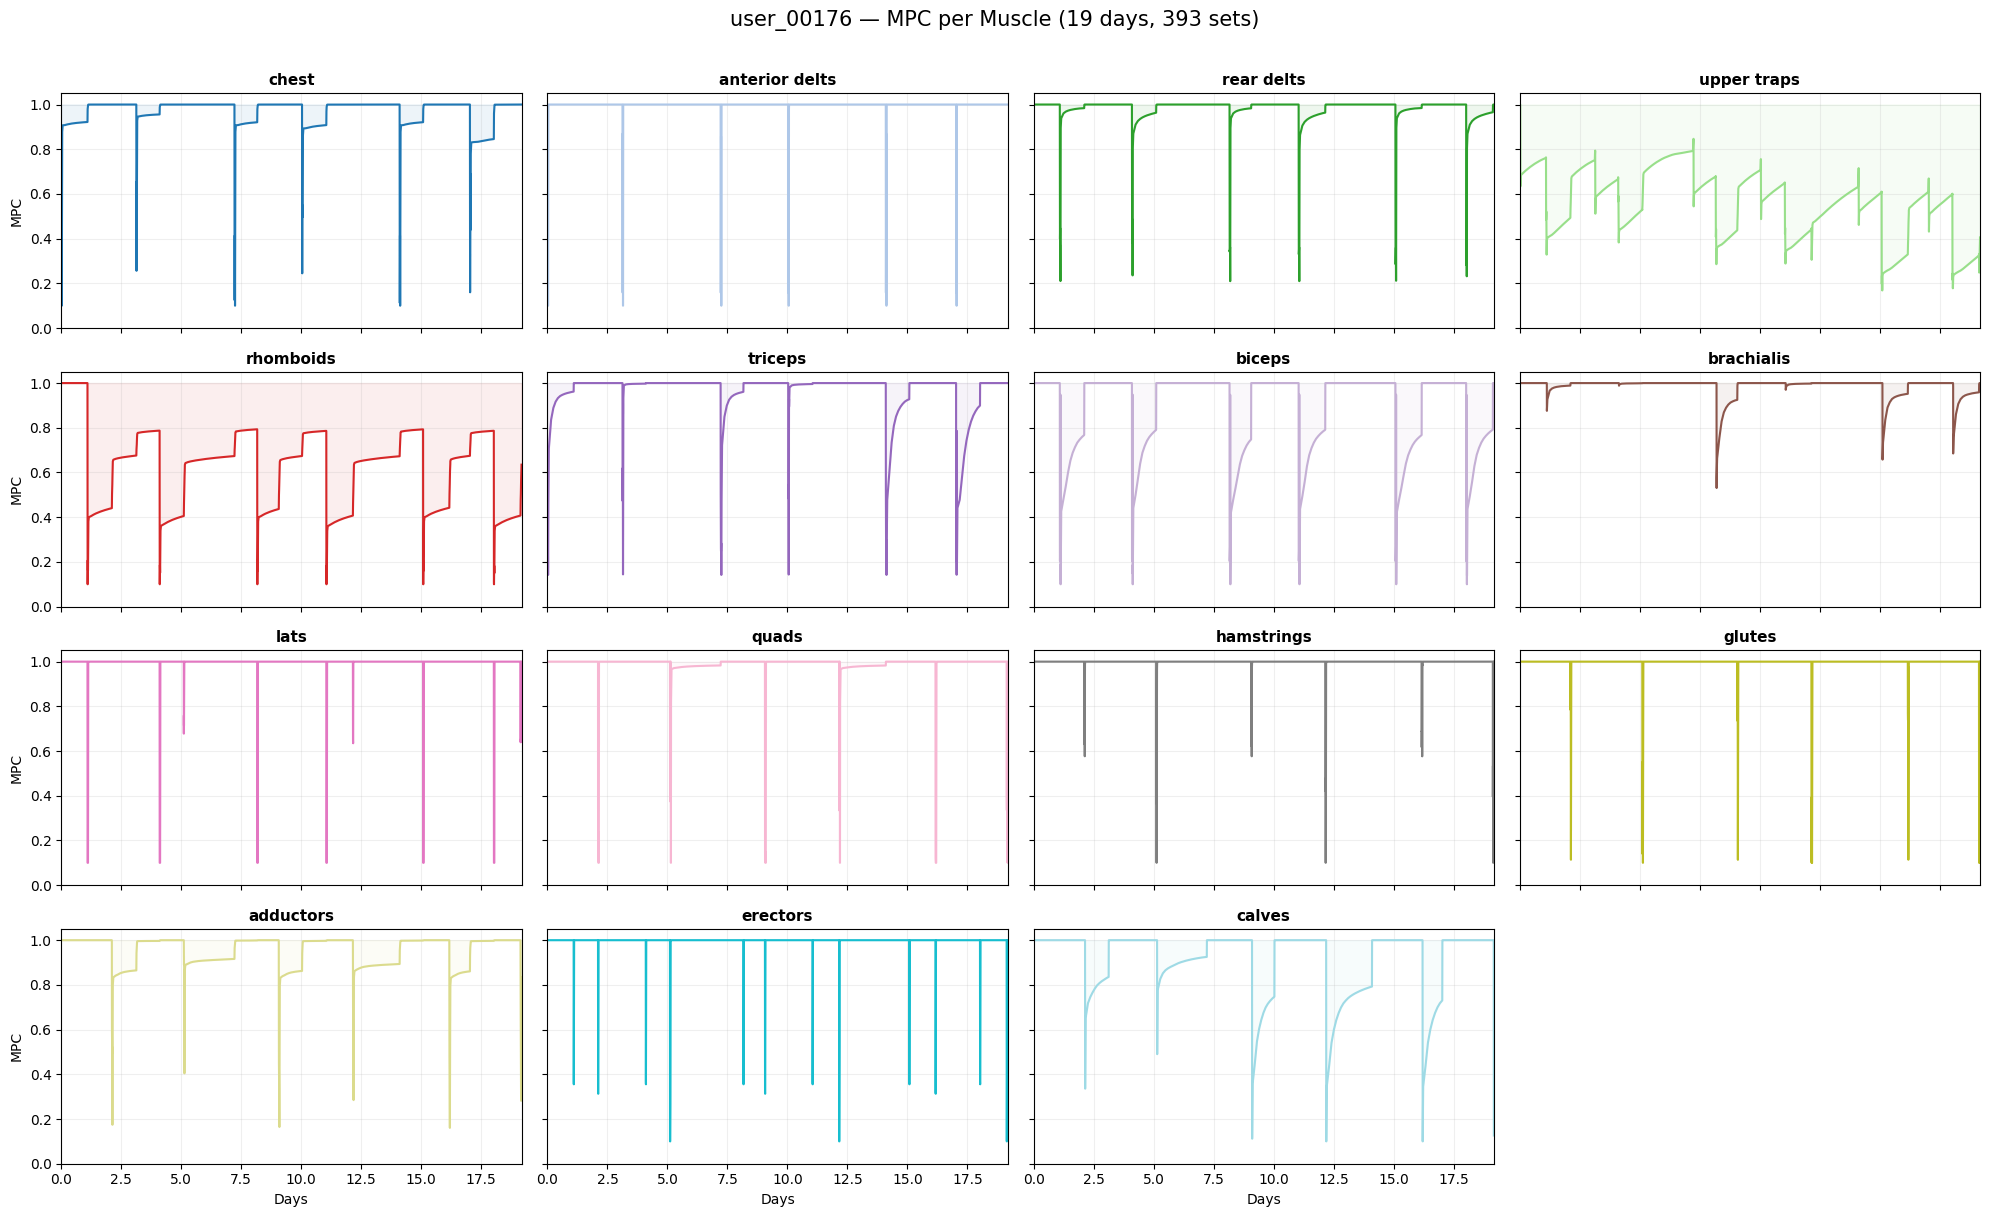

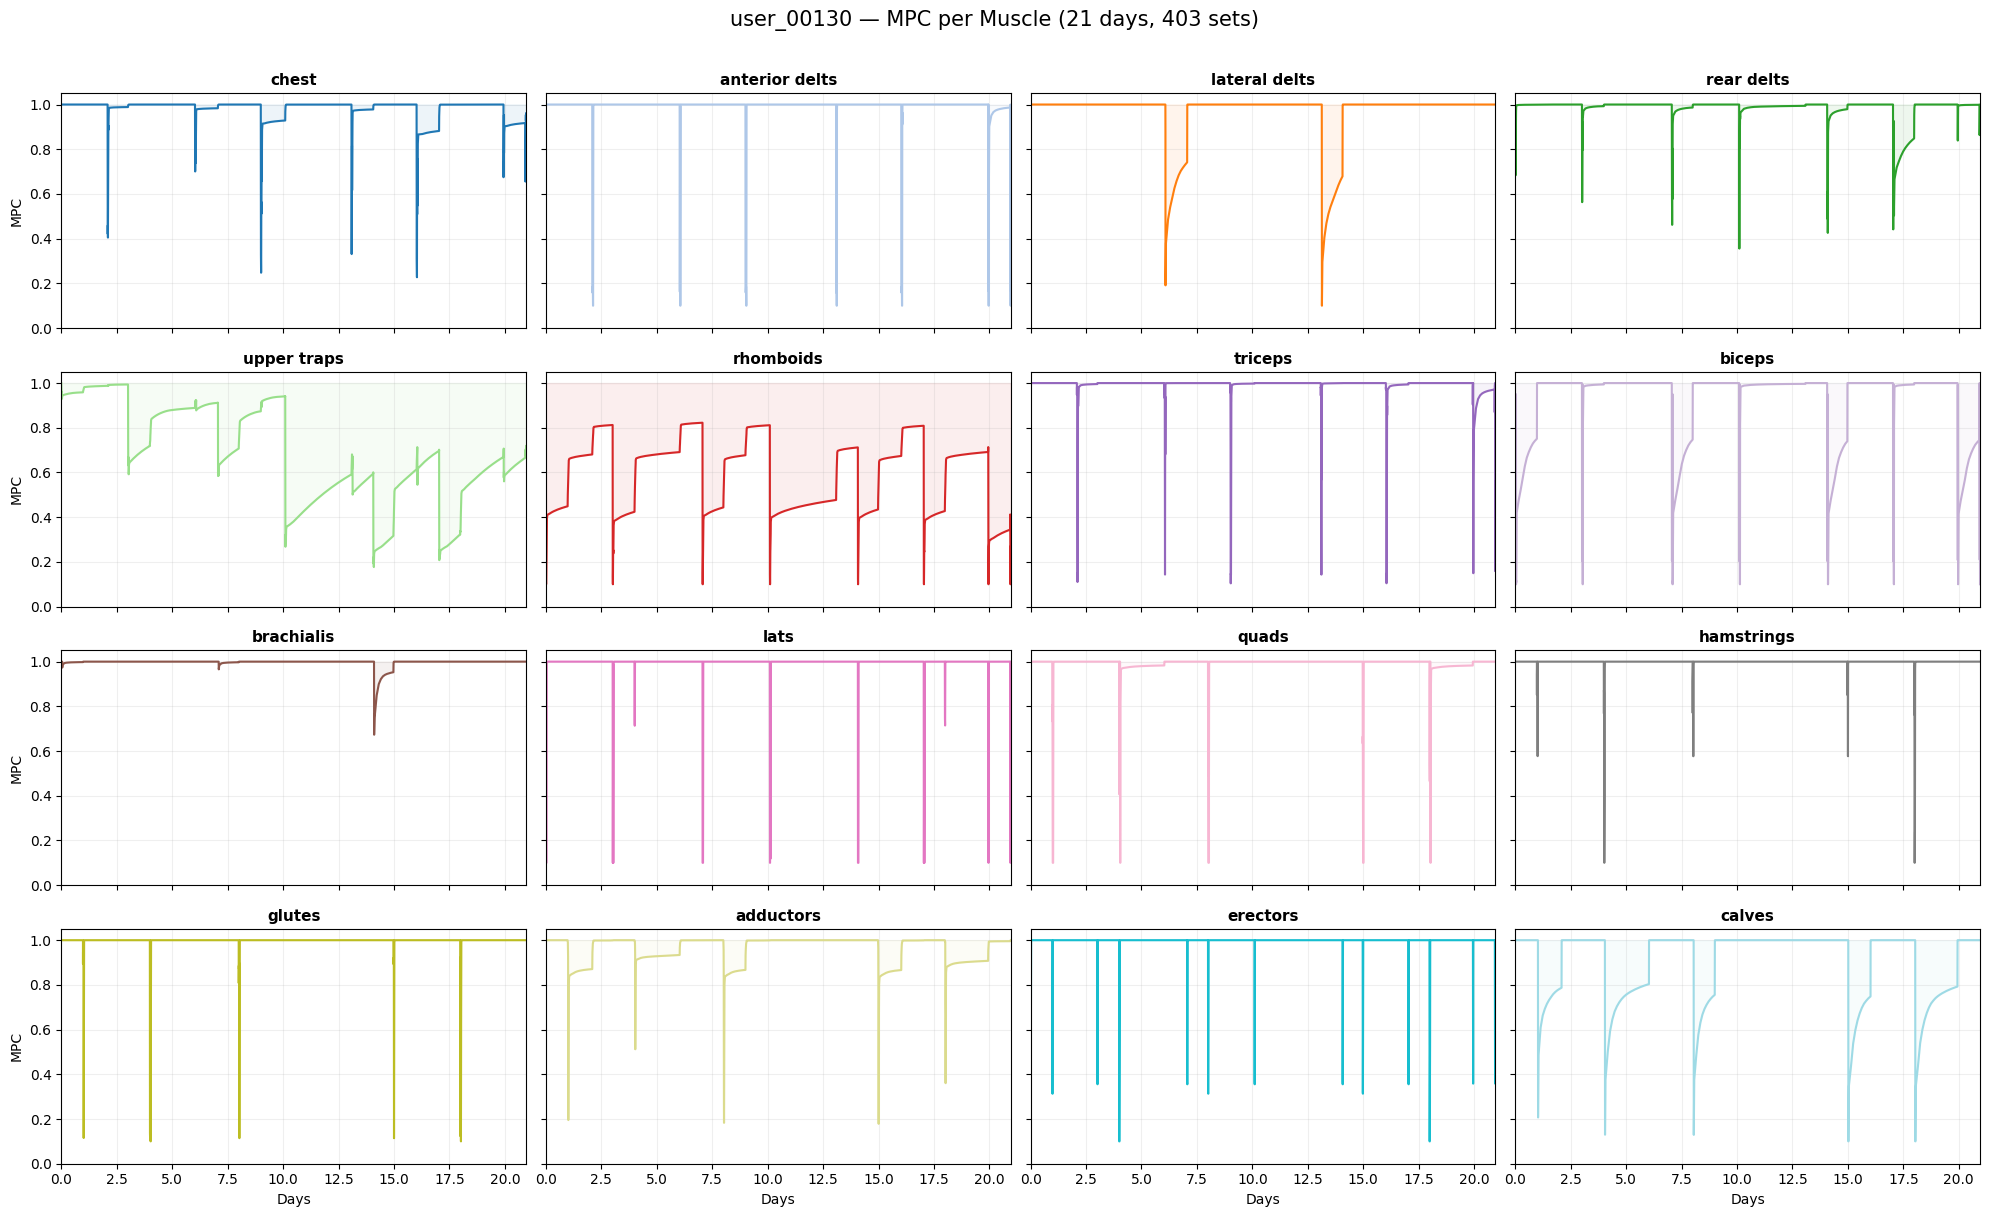

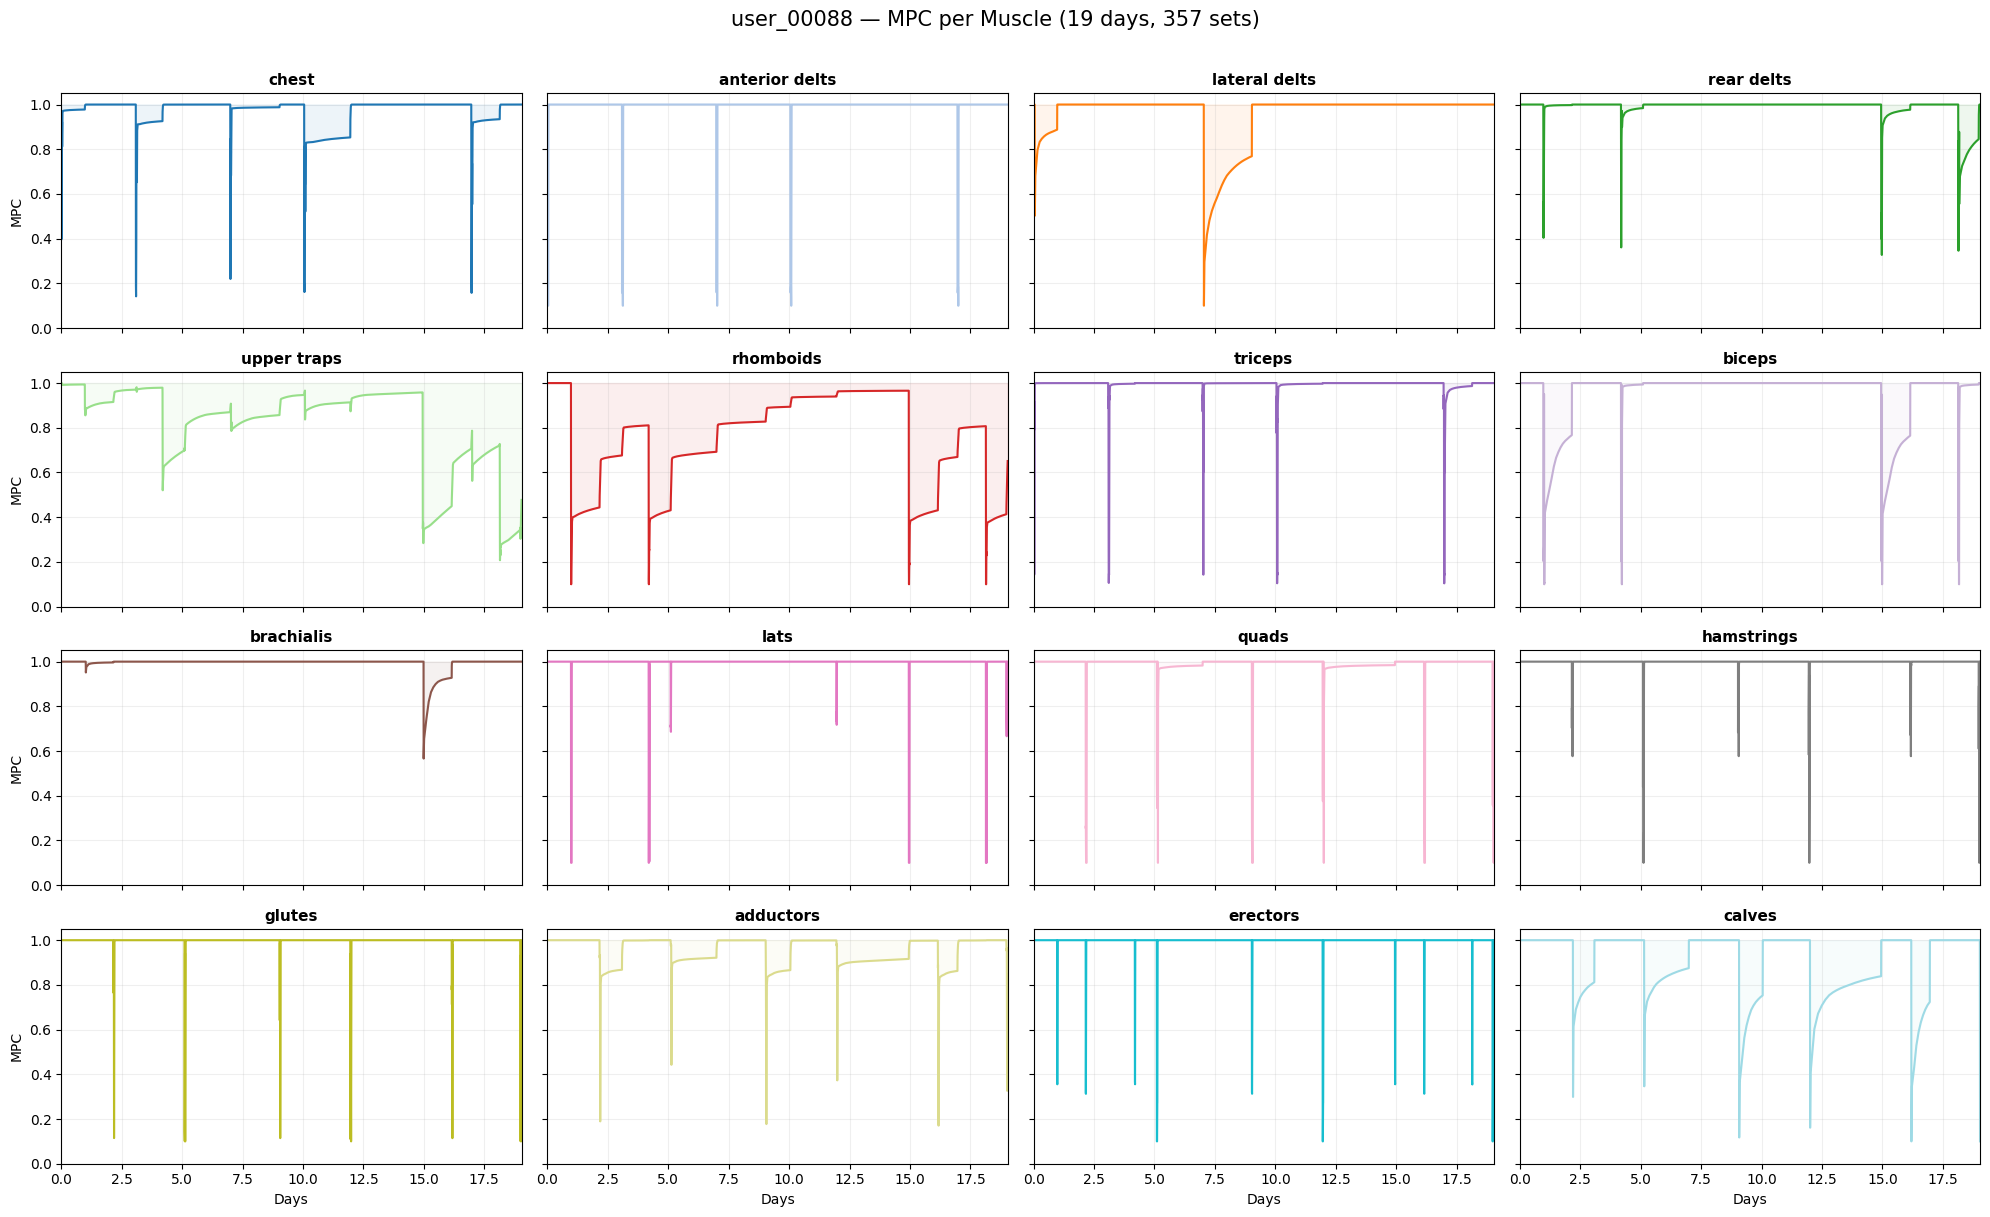

In [ ]:
# --- MPC Per Muscle Per User (3 users × 16 muscles, 3 weeks) ---
# Smooth recovery curves by querying r_net between sets
test_sequences = build_user_sequences(test_df)
sample_users = sorted(test_sequences, key=lambda s: len(s["exercise_idx"]), reverse=True)[:3]
muscle_colors = plt.cm.tab20(np.linspace(0, 1, NUM_MUSCLES))

INTERP_PER_GAP = 20  # points between consecutive sets

for seq in sample_users:
    ts = seq["timestamps"]
    t0 = ts[0]
    hours_all = np.array([(t - t0) / np.timedelta64(1, "h") for t in ts])
    mask_3w = hours_all <= 504
    T_plot = max(int(mask_3w.sum()), min(len(seq["exercise_idx"]), 300))

    # Get MPC after each set
    with torch.no_grad():
        _, mh = model.forward_with_mpc_history(
            seq["exercise_idx"][:T_plot].unsqueeze(0).to(DEVICE),
            seq["weight"][:T_plot].unsqueeze(0).to(DEVICE),
            seq["reps"][:T_plot].unsqueeze(0).to(DEVICE),
            seq["rir"][:T_plot].unsqueeze(0).to(DEVICE),
            seq["delta_t"][:T_plot].unsqueeze(0).to(DEVICE))

    hours = hours_all[:T_plot]
    mpc_post = mh[1:]  # (T_plot, 16) — MPC after each set

    # Build smooth trajectory: for each gap between sets, interpolate recovery
    me_all = model.muscle_embed(torch.arange(NUM_MUSCLES, device=DEVICE))
    smooth_hours = []
    smooth_mpc = []

    with torch.no_grad():
        for t in range(T_plot):
            # Point at set time (post-fatigue)
            smooth_hours.append(hours[t])
            smooth_mpc.append(mpc_post[t])

            # Interpolate recovery until next set
            if t < T_plot - 1:
                gap_hours = hours[t + 1] - hours[t]
                if gap_hours > 0.5:  # only interpolate gaps > 30 min
                    n_pts = min(INTERP_PER_GAP, max(3, int(gap_hours / 2)))
                    dt_samples = np.linspace(0.5, gap_hours - 0.01, n_pts)
                    for dt_h in dt_samples:
                        mpc_start = torch.tensor(mpc_post[t], dtype=torch.float32, device=DEVICE)
                        dt_norm = torch.full((NUM_MUSCLES,),
                                            float(np.log1p(dt_h) / DT_SCALE),
                                            dtype=torch.float32, device=DEVICE)
                        recovered = model.r_net(mpc_start, dt_norm, me_all).cpu().numpy()
                        smooth_hours.append(hours[t] + dt_h)
                        smooth_mpc.append(recovered)

    # Sort by time
    order = np.argsort(smooth_hours)
    smooth_hours = np.array(smooth_hours)[order]
    smooth_mpc = np.array(smooth_mpc)[order]
    days = smooth_hours / 24.0

    # Find active muscles
    used = seq["exercise_idx"][:T_plot].numpy()
    active_muscles = [mi for mi in range(NUM_MUSCLES) if np.any(INVOLVEMENT_MATRIX[used, mi] > 0)]

    n_active = len(active_muscles)
    n_cols = 4
    n_rows = math.ceil(n_active / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows), sharex=True, sharey=True)
    fig.suptitle(f"{seq['user_id']} — MPC per Muscle ({days[-1]:.0f} days, {T_plot} sets)",
                 fontsize=15, y=1.01)

    for idx, mi in enumerate(active_muscles):
        ax = axes[idx // n_cols, idx % n_cols] if n_rows > 1 else axes[idx % n_cols]
        ax.plot(days, smooth_mpc[:, mi], color=muscle_colors[mi], linewidth=1.5)
        ax.fill_between(days, smooth_mpc[:, mi], 1.0, alpha=0.08, color=muscle_colors[mi])
        ax.set_title(ALL_MUSCLES[mi].replace("_", " "), fontsize=11, fontweight="bold")
        ax.set_ylim(0.0, 1.05)
        ax.set_xlim(days[0], days[-1])
        ax.grid(True, alpha=0.2)
        if idx // n_cols == n_rows - 1:
            ax.set_xlabel("Days")
        if idx % n_cols == 0:
            ax.set_ylabel("MPC")

    total_slots = n_rows * n_cols
    for idx in range(n_active, total_slots):
        ax = axes[idx // n_cols, idx % n_cols] if n_rows > 1 else axes[idx % n_cols]
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# --- Learned Recovery Curves (multiple starting MPCs) ---
dt_hours = np.linspace(0, 96, 300)
dt_norm = np.log1p(dt_hours) / DT_SCALE
muscle_colors = plt.cm.tab20(np.linspace(0, 1, NUM_MUSCLES))

start_mpcs = [0.1, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(1, len(start_mpcs), figsize=(24, 6), sharey=True)

with torch.no_grad():
    for col, mpc0 in enumerate(start_mpcs):
        ax = axes[col]
        for mi in range(NUM_MUSCLES):
            me = model.muscle_embed(torch.tensor([mi], device=DEVICE)).expand(len(dt_norm), -1)
            mpc_start = torch.full((len(dt_norm),), mpc0, device=DEVICE)
            dt_tensor = torch.tensor(dt_norm, dtype=torch.float32, device=DEVICE)
            rec = model.r_net(mpc_start, dt_tensor, me).cpu().numpy()
            ax.plot(dt_hours, rec, label=ALL_MUSCLES[mi].replace("_", " "),
                    color=muscle_colors[mi], linewidth=1.5, alpha=0.8)
        ax.axhline(1.0, color="gray", ls=":", alpha=0.5)
        ax.axhline(mpc0, color="gray", ls=":", alpha=0.5)
        ax.set_xlabel("Time (hours)")
        ax.set_title(f"Starting MPC = {mpc0}")
        ax.set_ylim(0.0, 1.05)
        ax.grid(True, alpha=0.2)
        if col == 0:
            ax.set_ylabel("MPC")

axes[0].legend(fontsize=6, ncol=2, loc="lower right")
plt.suptitle("Learned Recovery Curves — r(mpc, Δt) at Different Starting Fatigue Levels", fontsize=14)
plt.tight_layout()
plt.show()

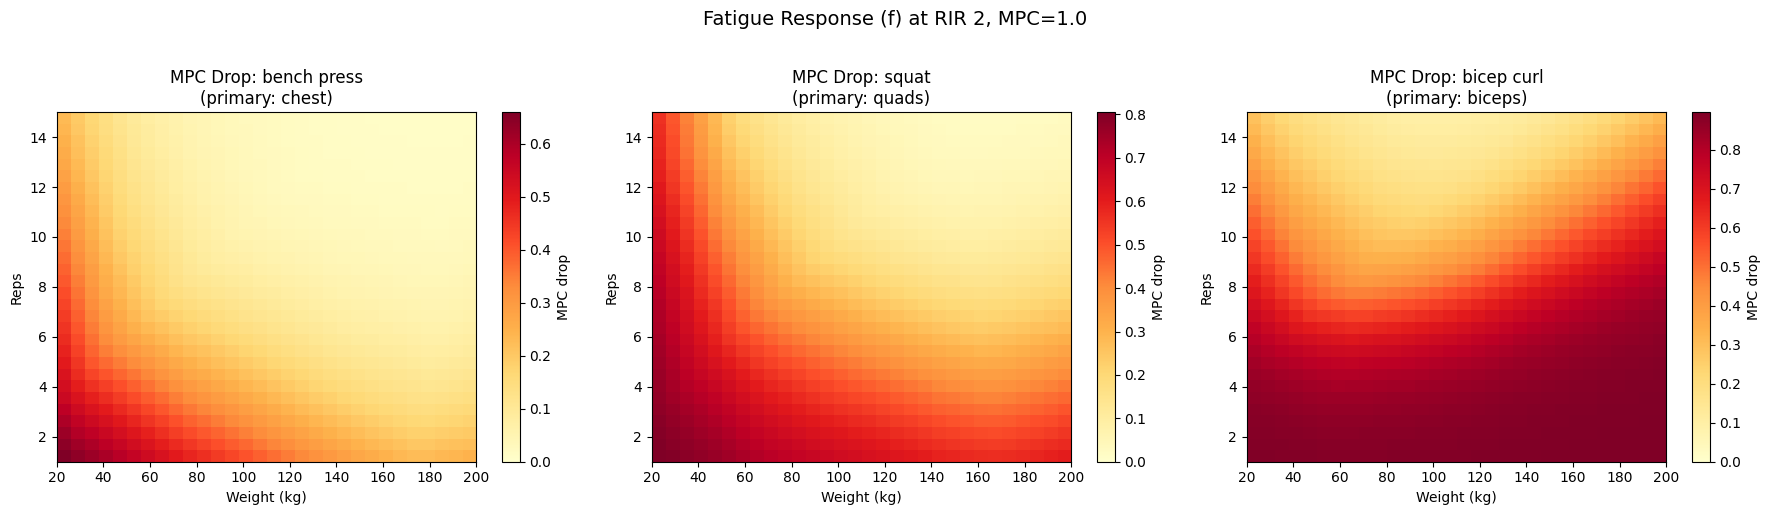

In [ ]:
# --- Fatigue Heatmaps ---
probe_ex = ["bench_press", "squat", "bicep_curl"]
w_range = np.linspace(0.1, 1.0, 30)
r_range = np.linspace(0.03, 0.5, 30)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
with torch.no_grad():
    for col, ex in enumerate(probe_ex):
        ei = EXERCISE_TO_IDX[ex]; ms = EXERCISE_MUSCLES[ex]
        pm = max(ms, key=ms.get); mi = MUSCLE_TO_IDX[pm]
        ee = model.exercise_embed(torch.tensor([ei], device=DEVICE))
        me = model.muscle_embed(torch.tensor([mi], device=DEVICE))
        grid = np.zeros((len(r_range), len(w_range)))
        for ri, rv in enumerate(r_range):
            for wi, wv in enumerate(w_range):
                d = model.f_net(
                    torch.tensor([wv], dtype=torch.float32, device=DEVICE),
                    torch.tensor([rv], dtype=torch.float32, device=DEVICE),
                    torch.tensor([0.4], dtype=torch.float32, device=DEVICE),
                    torch.tensor([1.0], dtype=torch.float32, device=DEVICE), ee, me).item()
                grid[ri, wi] = d * ms[pm]
        ax = axes[col]
        im = ax.imshow(grid, aspect="auto", origin="lower", extent=[20,200,1,15], cmap="YlOrRd", vmin=0)
        ax.set_xlabel("Weight (kg)"); ax.set_ylabel("Reps")
        ax.set_title(f"MPC Drop: {ex.replace('_',' ')}\n(primary: {pm})")
        plt.colorbar(im, ax=ax, label="MPC drop")
plt.suptitle("Fatigue Response (f) at RIR 2, MPC=1.0", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

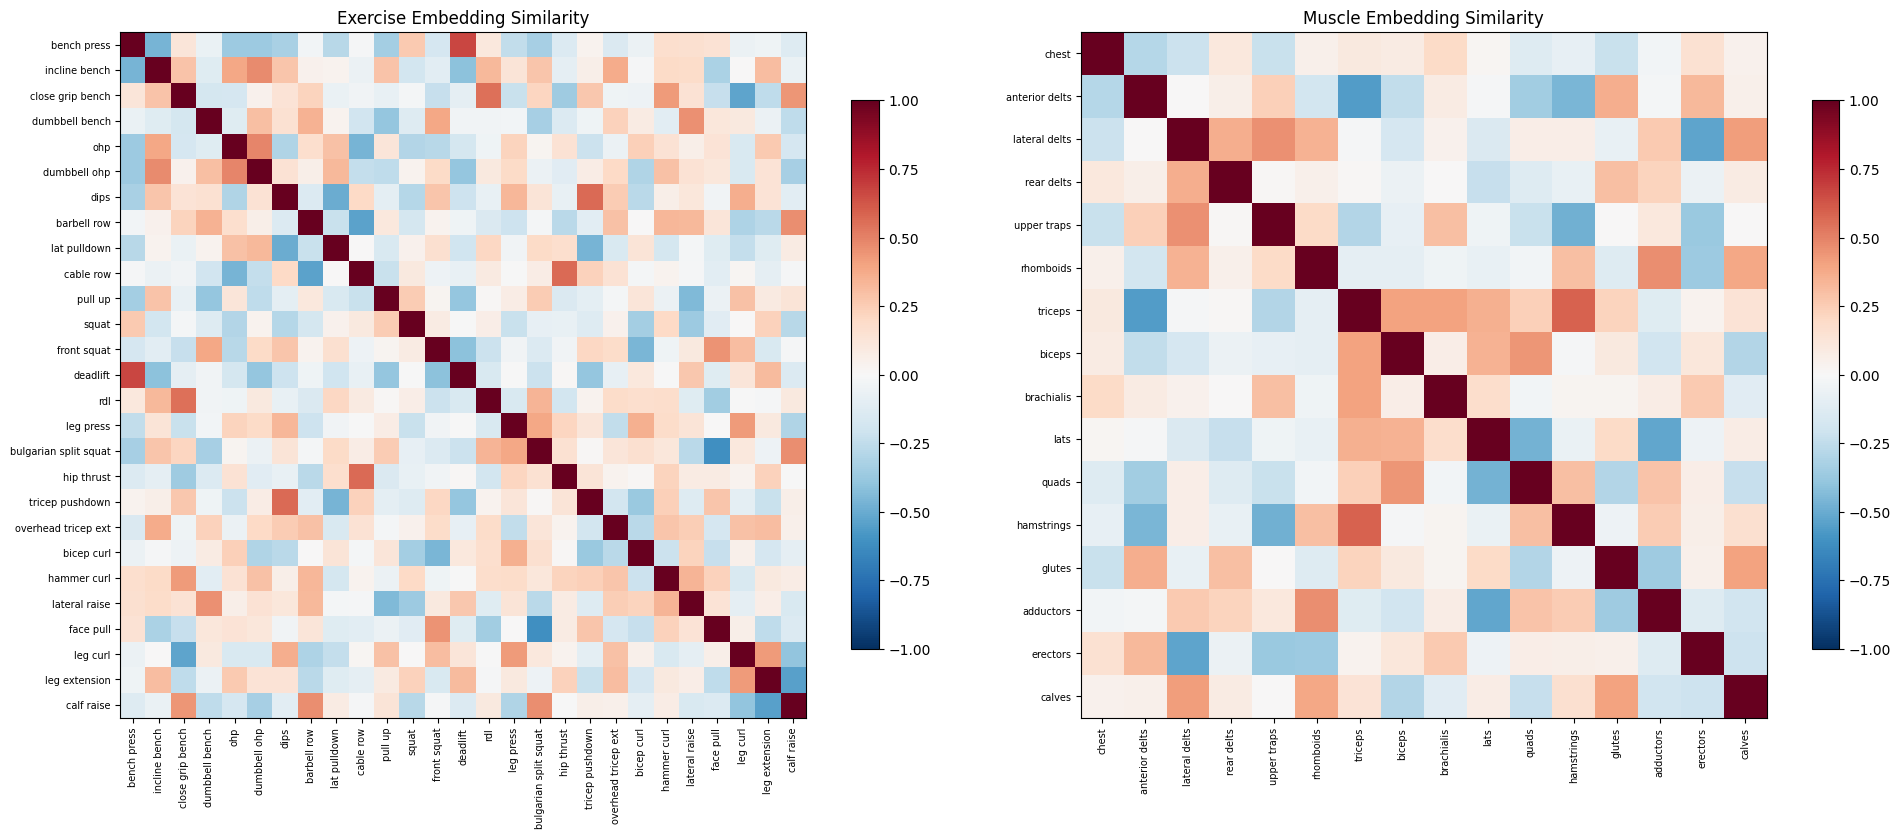

In [ ]:
# --- Embedding Similarity ---
with torch.no_grad():
    ex_emb = model.exercise_embed.weight.cpu().numpy()
    m_emb = model.muscle_embed.weight.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, emb, labels, title in [
    (axes[0], ex_emb, [e.replace("_"," ") for e in ALL_EXERCISES], "Exercise Embedding Similarity"),
    (axes[1], m_emb, [m.replace("_"," ") for m in ALL_MUSCLES], "Muscle Embedding Similarity")]:
    N = len(emb)
    sim = np.array([[np.dot(emb[i],emb[j])/(norm(emb[i])*norm(emb[j])+1e-8) for j in range(N)] for i in range(N)])
    im = ax.imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    ax.set_xticklabels(labels, rotation=90, fontsize=7); ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(title); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

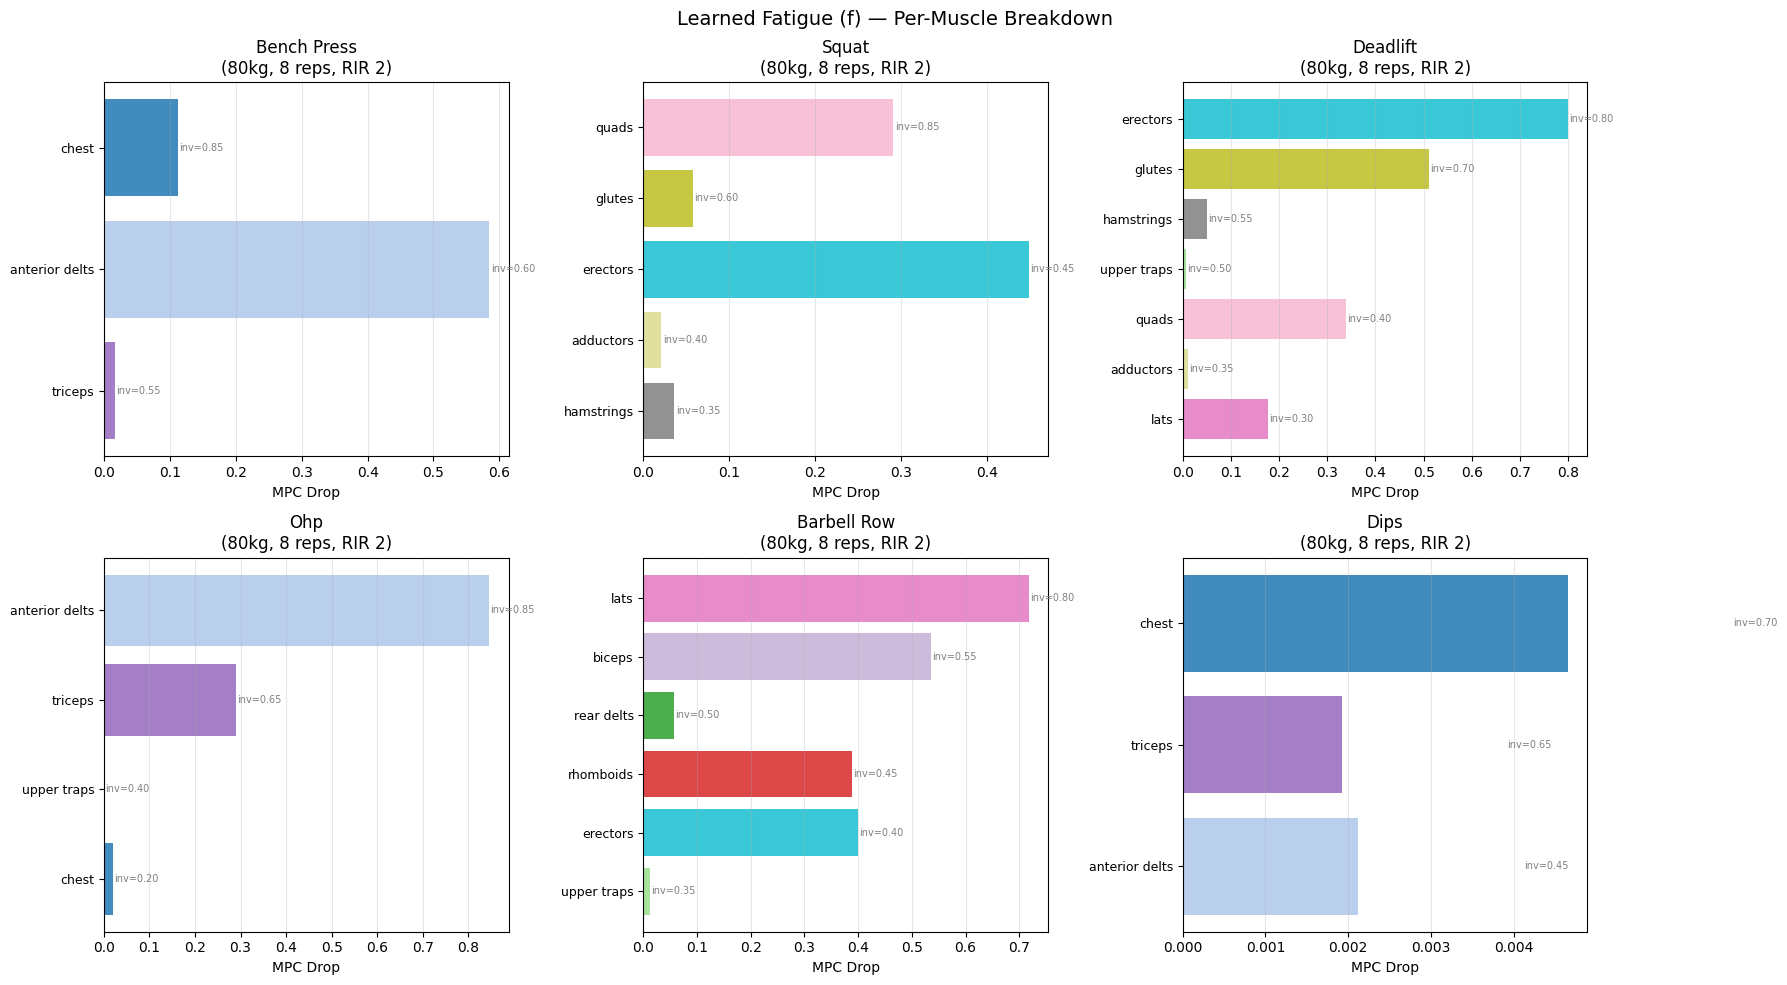

In [ ]:
# --- Per-Muscle Fatigue Breakdown ---
probe_ex = ["bench_press", "squat", "deadlift", "ohp", "barbell_row", "dips"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
F = torch.float32
with torch.no_grad():
    for idx, ex in enumerate(probe_ex):
        ax = axes[idx//3, idx%3]; ei = EXERCISE_TO_IDX[ex]; ms = EXERCISE_MUSCLES[ex]
        ee = model.exercise_embed(torch.tensor([ei], device=DEVICE))
        involved = sorted(ms.keys(), key=lambda m: ms[m], reverse=True)
        drops, cols = [], []
        for m in involved:
            me = model.muscle_embed(torch.tensor([MUSCLE_TO_IDX[m]], device=DEVICE))
            d = model.f_net(torch.tensor([0.4],dtype=F,device=DEVICE), torch.tensor([0.27],dtype=F,device=DEVICE),
                torch.tensor([0.4],dtype=F,device=DEVICE), torch.tensor([1.0],dtype=F,device=DEVICE), ee, me).item()
            drops.append(d * ms[m]); cols.append(muscle_colors[MUSCLE_TO_IDX[m]])
        labs = [m.replace("_"," ") for m in involved]
        ax.barh(range(len(labs)), drops, color=cols, alpha=0.85)
        ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=9)
        ax.set_xlabel("MPC Drop"); ax.set_title(f"{ex.replace('_',' ').title()}\n(80kg, 8 reps, RIR 2)")
        ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis="x")
        for i, (d, m) in enumerate(zip(drops, involved)):
            ax.text(d+0.002, i, f"inv={ms[m]:.2f}", va="center", fontsize=7, color="gray")
plt.suptitle("Learned Fatigue (f) — Per-Muscle Breakdown", fontsize=14)
plt.tight_layout(); plt.show()

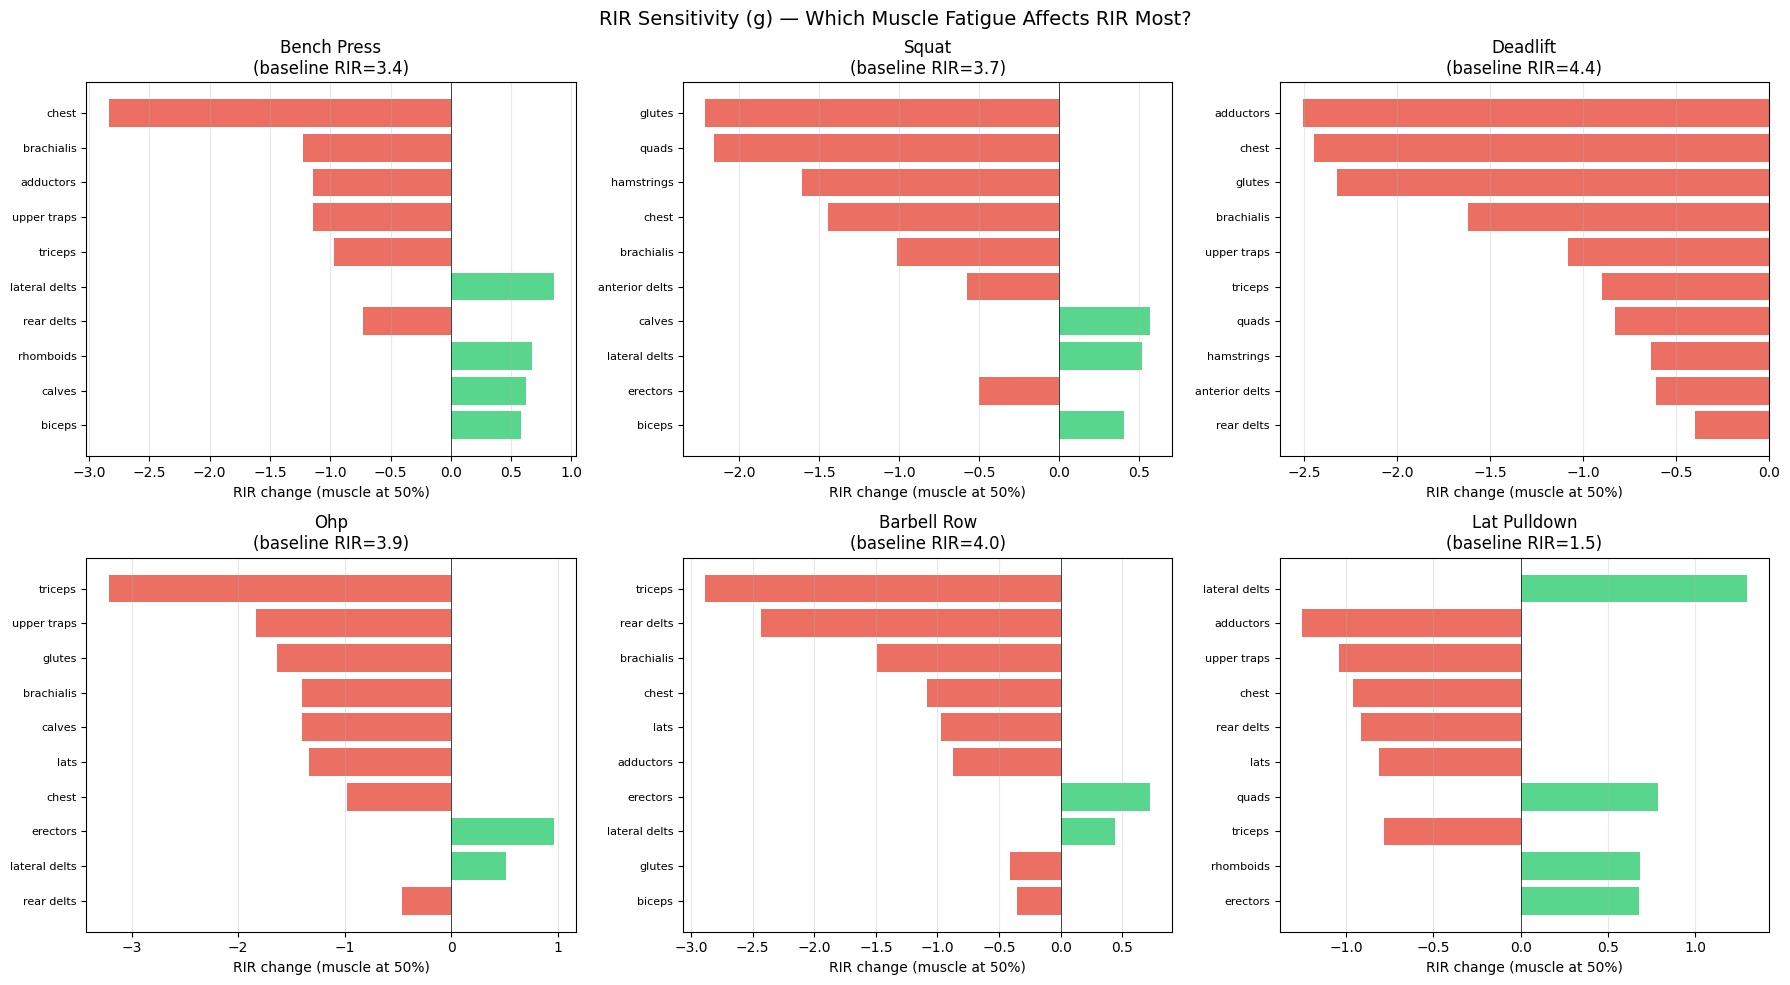

In [ ]:
# --- RIR Sensitivity — Which muscles matter most per exercise? ---
probe_ex = ["bench_press", "squat", "deadlift", "ohp", "barbell_row", "lat_pulldown"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
F = torch.float32
with torch.no_grad():
    for idx, ex in enumerate(probe_ex):
        ax = axes[idx//3, idx%3]; ei = EXERCISE_TO_IDX[ex]
        ee = model.exercise_embed(torch.tensor([ei], device=DEVICE))
        w = torch.tensor([0.4], dtype=F, device=DEVICE)
        r = torch.tensor([0.27], dtype=F, device=DEVICE)
        mpc_base = torch.ones(1, NUM_MUSCLES, device=DEVICE)
        rir_base = model.g_net(w, r, ee, mpc_base).item() * RIR_SCALE
        deltas = {}
        for mi in range(NUM_MUSCLES):
            mpc_test = torch.ones(1, NUM_MUSCLES, device=DEVICE)
            mpc_test[0, mi] = 0.5
            rir_test = model.g_net(w, r, ee, mpc_test).item() * RIR_SCALE
            deltas[ALL_MUSCLES[mi]] = rir_test - rir_base
        sd = sorted(deltas.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
        names = [m.replace("_"," ") for m, _ in sd]
        vals = [d for _, d in sd]
        cols = ["#e74c3c" if d < 0 else "#2ecc71" for d in vals]
        ax.barh(range(len(names)), vals, color=cols, alpha=0.8)
        ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
        ax.set_xlabel("RIR change (muscle at 50%)"); ax.set_title(f"{ex.replace('_',' ').title()}\n(baseline RIR={rir_base:.1f})")
        ax.axvline(0, color="black", linewidth=0.5); ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis="x")
plt.suptitle("RIR Sensitivity (g) — Which Muscle Fatigue Affects RIR Most?", fontsize=14)
plt.tight_layout(); plt.show()

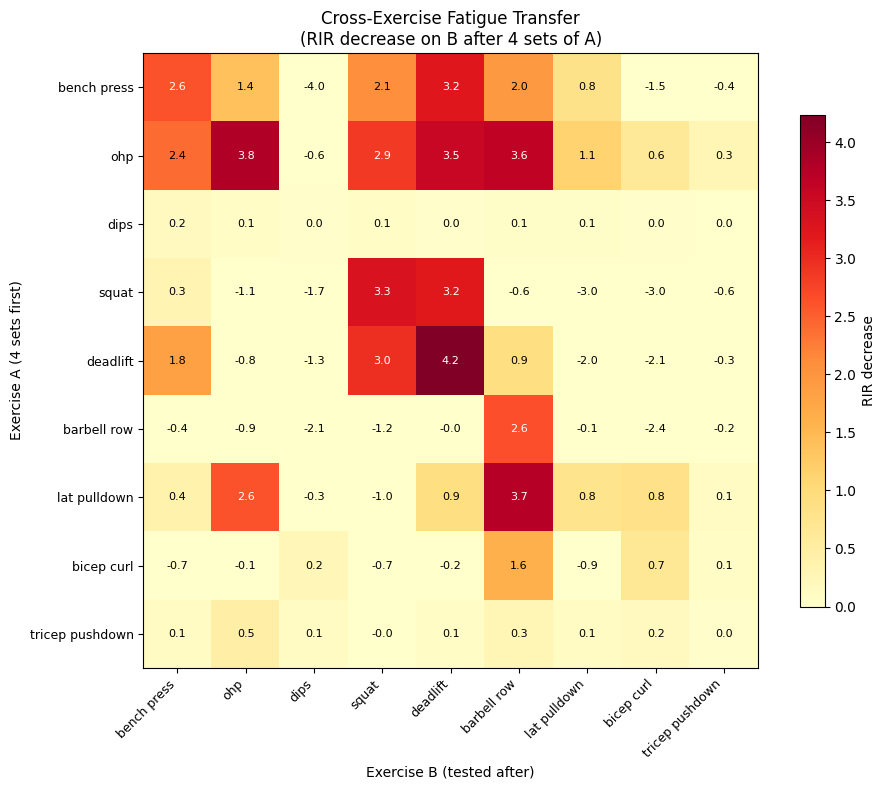

In [ ]:
# --- Cross-Exercise Fatigue Transfer Matrix ---
transfer_ex = ["bench_press","ohp","dips","squat","deadlift","barbell_row","lat_pulldown","bicep_curl","tricep_pushdown"]
n = len(transfer_ex)
tmat = np.zeros((n, n))
F = torch.float32
with torch.no_grad():
    for i, ea in enumerate(transfer_ex):
        for j, eb in enumerate(transfer_ex):
            mpc_fresh = torch.ones(1, NUM_MUSCLES, device=DEVICE)
            eeb = model.exercise_embed(torch.tensor([EXERCISE_TO_IDX[eb]], device=DEVICE))
            wb = torch.tensor([0.4], dtype=F, device=DEVICE)
            rb = torch.tensor([0.27], dtype=F, device=DEVICE)
            rir_fresh = model.g_net(wb, rb, eeb, mpc_fresh).item() * RIR_SCALE

            mpc = torch.ones(1, NUM_MUSCLES, device=DEVICE)
            me = model.muscle_embed(torch.arange(NUM_MUSCLES, device=DEVICE)).unsqueeze(0)
            Ed = me.shape[-1]
            eea = model.exercise_embed(torch.tensor([EXERCISE_TO_IDX[ea]], device=DEVICE))
            for _ in range(4):
                inv = model.involvement[torch.tensor([EXERCISE_TO_IDX[ea]], device=DEVICE)]
                drop = model.f_net(
                    torch.tensor([0.4],dtype=F,device=DEVICE).unsqueeze(1).expand(-1,NUM_MUSCLES).reshape(-1),
                    torch.tensor([0.27],dtype=F,device=DEVICE).unsqueeze(1).expand(-1,NUM_MUSCLES).reshape(-1),
                    torch.tensor([0.4],dtype=F,device=DEVICE).unsqueeze(1).expand(-1,NUM_MUSCLES).reshape(-1),
                    mpc.reshape(-1), eea.unsqueeze(1).expand(-1,NUM_MUSCLES,-1).reshape(-1,Ed),
                    me.reshape(-1,Ed)).reshape(1, NUM_MUSCLES)
                mpc = (mpc * (1.0 - inv * drop)).clamp(min=0.1)
            rir_fat = model.g_net(wb, rb, eeb, mpc).item() * RIR_SCALE
            tmat[i, j] = rir_fresh - rir_fat

fig, ax = plt.subplots(figsize=(10, 8))
labs = [e.replace("_"," ") for e in transfer_ex]
im = ax.imshow(tmat, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labs, rotation=45, ha="right", fontsize=9); ax.set_yticklabels(labs, fontsize=9)
ax.set_xlabel("Exercise B (tested after)"); ax.set_ylabel("Exercise A (4 sets first)")
ax.set_title("Cross-Exercise Fatigue Transfer\n(RIR decrease on B after 4 sets of A)")
for i in range(n):
    for j in range(n):
        c = "white" if tmat[i,j] > tmat.max()*0.6 else "black"
        ax.text(j, i, f"{tmat[i,j]:.1f}", ha="center", va="center", fontsize=8, color=c)
plt.colorbar(im, ax=ax, label="RIR decrease", shrink=0.8)
plt.tight_layout(); plt.show()